# $\lambda$ and $\rho$ across start dates: DJF, 45 hindcasts

`granger_lin_lambda_m.ipynb` computes these metrics with the sample axis running over
*months inside one hindcast* ($T=120$, start date decadal1961). Here the sample axis runs
over *start dates*: $J=45$ DJF means, one per hindcast, 29 members from four CMIP5 decadal
models, verifying against HadSLP2r. Successive entries are separate forecasts rather than
successive months, which is the axis Eade et al. (2014) score.

The formulas are unchanged. With $s_{-n}$ the ensemble mean over the other $N-1$ members
and $g$ the observations,

$$\lambda_m = \frac1N\sum_n\sqrt{1-2^{-2I(f_n;\,s_{-n})}},\qquad
  \rho_m = \frac1N\sum_n\mathrm{corr}\big(f_n,\,s_{-n}\big)$$

$$\lambda_o = \frac1N\sum_n\sqrt{1-2^{-2I(f_n;\,g)}},\qquad
  \rho_o = \frac1N\sum_n\mathrm{corr}\big(f_n,\,g\big)$$

plus the ensemble-mean pair $\lambda_o^s,\rho_o^s$ from $I(s;g)$ and $\mathrm{corr}(s,g)$,
and the ratios that stand in for RPC. $\lambda$ is formed per member and *then* averaged,
as there.

Two things about $J=45$ shape everything below, and neither applies at $T=120$.

**The estimator floor.** The KSG permutation null at $J=45$ is about 0.05 bits, i.e.
$\lambda\approx0.26$ out of independent noise -- larger than most of the signal. Every
$\lambda$ here is $I$ minus that null, re-estimated at this sample size rather than
carried over.

**Where the comparison lives.** A single N48 grid cell at $J=45$ has too little
signal-to-noise for either metric: per cell the observation-side excess $I$ sits at zero
and $\rho_o$ averages under 0.1. Eade et al.'s RPC $>1$ results are not per-cell numbers --
they are area-averaged indices, and their maps are smoothed over $12.5^\circ\times
11.25^\circ$. The per-cell maps below are kept for continuity with the $T=120$ notebook,
but the index section is the part comparable to the paper, and it carries a validation
against the one external scalar the study anchors on.

## The DJF cube, and two verification windows

`scripts/build_djf_cube.py` reduces the 9.5 GB of raw monthly `psl` under
`.scratch/eade_replication/fetch` to one winter mean per (start date, member) on HadCM3's
N48 grid. A DJF season is labelled by the January it ends in, and the lead-time convention
is asserted per file: for start-date index $j$ every model's output begins Jan($1961+j$),
so lead year 1 is $1961+j$. Two windows come out of one pass, both DJF:

* **lead 2-5** -- the four winters inside lead years 2-5, averaged. This is the winter-only
  analogue of Eade et al.'s published lead-years-2-5 mean, and it is the primary window
  here for that reason.
* **lead 1** -- the first complete winter, Dec($1961+j$) with Jan and Feb of $1962+j$: one
  winter at 12-14 months lead, kept as the contrast. It shows how much of the skill is the
  multi-winter average rather than a single seasonal forecast.

Observations are HadSLP2r over the matching months on the same grid. All 1305 (start date,
member) pairs are complete, so nothing is dropped or zero-filled and every series below is
45 points long.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)

_z = np.load("../data/djf_cube.npz")          # scripts/build_djf_cube.py
lats, lons, members = _z["lat"], _z["lon"], _z["members"]

WINDOWS = ["lead 2-5", "lead 1"]
_RAW = {"lead 2-5": (_z["cube25"], _z["obs25"]), "lead 1": (_z["cube"], _z["obs"])}
WINTER = 1962 + _z["j"]                       # DJF labelled by the January it ends in
J, N = _z["cube"].shape[0], _z["cube"].shape[1]

W = np.cos(np.deg2rad(lats))[:, None] * np.ones(len(lons))    # N48 spans both poles


def gm(a):
    """Area-weighted global mean, NaNs skipped. Plain means over-weight the polar rows."""
    m = np.isfinite(a)
    return float((a[m] * W[m]).sum() / W[m].sum())


PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180           # grid is 0..356.25E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title, order=None, extent=None):
    ax.set_global()
    h = ax.imshow(field[:, ORDER if order is None else order], origin="lower",
                  extent=EXTENT if extent is None else extent, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=12)
    return h


print("%d members x %d start dates, DJF %d..%d (%d absent), grid %d x %d"
      % (N, J, WINTER[0], WINTER[-1], 46 - J, len(lats), len(lons)))
print("gaps in either window: %d"
      % sum(int(np.isnan(a).sum() + np.isnan(b).sum()) for a, b in _RAW.values()))

29 members x 45 start dates, DJF 1962..2007 (1 absent), grid 73 x 96
gaps in either window: 0


## Detrending

`R.load_data` detrends the monthly ensemble with a degree-1 fit, and a degree-1 fit
carries an intercept, so it removes the window mean along with the drift. The same is done
here along the start-date axis, per member and per grid cell, and to the observations:
`detrend` subtracts the least-squares line *and* the mean, so every series entering an
estimator has mean zero to machine precision. Detrending is linear, so detrending the
members detrends the ensemble mean too -- $\sigma^2_{\mathrm{sig}}$ and
$\sigma^2_{\mathrm{tot}}$ both come out trend-free from the one operation.

It matters more here than at $T=120$. Over DJF 1962-2007 both modelled and observed SLP
carry a forced trend, and a trend shared by two series is correlation that has nothing to
do with forecast skill. The table prints what leaving it in would buy; it is not a
rounding effect.

In [2]:
def detrend(X):
    """Remove the least-squares line along the start-date axis (axis 0), per grid cell.

    Takes the mean with it, so every returned series has mean zero to machine precision.
    """
    t = np.arange(X.shape[0], dtype=float)
    t -= t.mean()
    flat = X.reshape(X.shape[0], -1)
    slope = (t[:, None] * flat).sum(axis=0) / (t ** 2).sum()
    return (flat - t[:, None] * slope - flat.mean(axis=0)).reshape(X.shape)


# (N, J, lat, lon) and (J, lat, lon), detrended, for each window
FIELDS = {w: (detrend(_RAW[w][0].astype(float)).transpose(1, 0, 2, 3),
              detrend(_RAW[w][1].astype(float)))
          for w in WINDOWS}


def loo_mean(Fx, n):
    """s_-n, the ensemble mean over the other N-1 members. No NaNs left to guard."""
    return (Fx.sum(axis=0) - Fx[n]) / (Fx.shape[0] - 1)


def pair(n, window):
    """(f_n, s_-n), both (J, lat, lon)."""
    Fx, _ = FIELDS[window]
    return Fx[n], loo_mean(Fx, n)


def pair_obs(n, window):
    """(f_n, g), both (J, lat, lon)."""
    Fx, Gx = FIELDS[window]
    return Fx[n], Gx


def rho_pair(x, y, axis=0):
    """Pearson along `axis`, vectorised over the trailing grid axes."""
    a = x - x.mean(axis=axis, keepdims=True)
    b = y - y.mean(axis=axis, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis) * (b ** 2).sum(axis))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, (a * b).sum(axis) / np.where(den > 0, den, 1), np.nan)


print("%-10s %13s %14s %10s %11s %10s %11s"
      % ("window", "max|mean| f", "obs trend/dec", "rho_o^s", "if trended",
         "rho_m", "if trended"))
for w in WINDOWS:
    Fx, Gx = FIELDS[w]
    Fr = _RAW[w][0].astype(float).transpose(1, 0, 2, 3)
    Gr = _RAW[w][1].astype(float)
    _t = np.arange(J, dtype=float)
    _t -= _t.mean()
    _sg = (_t[:, None] * Gr.reshape(J, -1)).sum(axis=0) / (_t ** 2).sum()
    print("%-10s %13.2e %11.1f Pa %10.4f %11.4f %10.4f %11.4f"
          % (w, np.abs(Fx.mean(axis=1)).max(), 10 * np.abs(_sg).max(),
             gm(rho_pair(Fx.mean(0), Gx)), gm(rho_pair(Fr.mean(0), Gr)),
             gm(np.sqrt(Fx.mean(0).var(0) / Fx.var(1).mean(0))),
             gm(np.sqrt(Fr.mean(0).var(0) / Fr.var(1).mean(0)))))

window       max|mean| f  obs trend/dec    rho_o^s  if trended      rho_m  if trended
lead 2-5        7.11e-12       232.8 Pa     0.0488      0.2040     0.2375      0.3098
lead 1          7.11e-12       186.3 Pa     0.1743      0.1892     0.3188      0.3575


## The permutation null at $J=45$

KSG has no analytic bias correction -- its digamma terms are the estimator, not a
correction layered on top -- so the floor has to be resampled.
`estimator.statistical_test(n_tests, method="permutation_test")` permutes the first
variable, leaves the other alone, and returns the null distribution of $I$ under
independence; its mean is the floor.

One constant covers every $I$ in this notebook, and that is not an approximation.
`R.mi_bits` rank-transforms both variables to uniform marginals before estimating, so a
permuted pair is a pair of independent rank vectors of length $J$ whatever grid cell,
member, window, index or spatial aggregation it came from: the null is a property of
$(J,k)$ alone. The samples below are pooled over both windows and both pairings, and the
across-case scatter is Monte-Carlo noise on 60 permutations. The last line is why this
section exists.

In [3]:
import infomeasure as im     # for the estimator objects, which carry statistical_test

K = 5                        # KSG neighbours, this project's default
NULL_POINTS = [(la, lo) for la in range(3, 73, 8) for lo in range(0, 96, 11)]
NULL_MEMBERS = [0, N // 3, 2 * N // 3, N - 1]
NULL_TESTS = 60


def lam(I):
    """sqrt(1 - 2^-2I), argument of the sqrt clamped at 0."""
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * I)))


def mi_null_bits(x, y, n_tests=NULL_TESTS):
    """Mean of the permutation null in bits, from infomeasure's statistical_test."""
    est = im.estimator(R.copula(x), R.copula(y), measure="mi", approach="ksg",
                       k=K, base=2, noise_level=0, minkowski_p=np.inf)
    return float(est.statistical_test(
        n_tests=n_tests, method="permutation_test").null_mean)


_samples = {}
for _w in WINDOWS:
    for _tag, _fn in (("s_-n", pair), ("g", pair_obs)):
        _out = []
        for _i, (_la, _lo) in enumerate(NULL_POINTS):
            _x, _y = _fn(NULL_MEMBERS[_i % len(NULL_MEMBERS)], _w)
            _out.append(mi_null_bits(_x[:, _la, _lo], _y[:, _la, _lo]))
        _samples[(_w, _tag)] = np.array(_out)

_all = np.concatenate(list(_samples.values()))
NULL_BITS = float(_all.mean())


def excess_mi(I):
    """I minus the permutation null, in bits. One floor, set by (J, k)."""
    return np.asarray(I, float) - NULL_BITS


print("%d points per case, %d cases, %d permutations each, %d nulls in total"
      % (len(NULL_POINTS), len(_samples), NULL_TESTS, _all.size))
print("%-12s %-6s %9s %12s" % ("window", "vs", "null", "across-case"))
for (_w, _tag), _s in _samples.items():
    print("%-12s %-6s %9.4f %12.4f" % (_w, _tag, _s.mean(), _s.std(ddof=1)))
print("\npooled null %.4f bits, se of mean %.4f  ->  lam(null) = %.4f"
      % (NULL_BITS, _all.std(ddof=1) / np.sqrt(_all.size), lam(NULL_BITS)))

81 points per case, 4 cases, 60 permutations each, 324 nulls in total
window       vs          null  across-case
lead 2-5     s_-n      0.0486       0.0108
lead 2-5     g         0.0494       0.0116
lead 1       s_-n      0.0500       0.0126
lead 1       g         0.0499       0.0131

pooled null 0.0495 bits, se of mean 0.0007  ->  lam(null) = 0.2574


## Per-cell fields

One KSG call per member per grid cell per window on the model side and the same on the
observation side: $4\times29\times73\times96$ estimates, a few minutes cold, so they are
cached. Pearson is vectorised and needs no cache. `rho_m deb` is the unbiased
signal-variance form,

$$\rho_m^{\mathrm{deb}}=\sqrt{\frac{N\,\mathrm{var}(s)-\sigma^2_{\mathrm{tot}}}
{(N-1)\,\sigma^2_{\mathrm{tot}}}},$$

which matters because $\mathbb E[\mathrm{var}(s)]=\sigma^2_{\mathrm{sig}}+
\sigma^2_{\mathrm{noise}}/N$: the plain $\rho_m=\sqrt{\mathrm{var}(s)/
\sigma^2_{\mathrm{tot}}}$ is biased *high*, so any RPC built on it is biased *low*.

Read the `I<0` column before the $\lambda$ columns -- it is the fraction of
observation-side member-cells whose excess $I$ is negative, i.e. clamped to $\lambda=0$.

In [4]:
CACHE = "../data/djf_lambda_cache.npz"


def mi_grid(pairfn, window):
    """I in bits for every member and grid cell, shape (N, lat, lon)."""
    x0, _ = pairfn(0, window)
    out = np.empty((N,) + x0.shape[1:])
    for n in range(N):
        x, y = pairfn(n, window)
        for la in range(out.shape[1]):
            for lo in range(out.shape[2]):
                out[n, la, lo] = R.mi_bits(x[:, la, lo], y[:, la, lo], "ksg", param=K)
    return out


def mi_field(x, y):
    """I in bits for a single (J, lat, lon) pair, shape (lat, lon)."""
    return np.array([[R.mi_bits(x[:, la, lo], y[:, la, lo], "ksg", param=K)
                      for lo in range(x.shape[2])] for la in range(x.shape[1])])


def key(prefix, w):
    return prefix + "_" + w.replace(" ", "")


if os.path.exists(CACHE):
    _c = np.load(CACHE)
    I_N = {w: _c[key("m", w)] for w in WINDOWS}
    I_O = {w: _c[key("o", w)] for w in WINDOWS}
else:
    I_N = {w: mi_grid(pair, w) for w in WINDOWS}
    I_O = {w: mi_grid(pair_obs, w) for w in WINDOWS}
    np.savez_compressed(CACHE, **{key("m", w): I_N[w] for w in WINDOWS},
                        **{key("o", w): I_O[w] for w in WINDOWS})

LAM_N, LAM_M, R_N, RHO_M = {}, {}, {}, {}
LAM_O_N, LAM_O, R_O_N, RHO_O = {}, {}, {}, {}
RHO_O_S, LAM_O_S, RHO_M_VAR, RHO_M_DEB = {}, {}, {}, {}
for w in WINDOWS:
    Fx, Gx = FIELDS[w]
    LAM_N[w] = lam(excess_mi(I_N[w]))
    LAM_M[w] = LAM_N[w].mean(axis=0)
    R_N[w] = np.stack([rho_pair(*pair(n, w)) for n in range(N)])
    RHO_M[w] = np.nanmean(R_N[w], axis=0)
    LAM_O_N[w] = lam(excess_mi(I_O[w]))
    LAM_O[w] = LAM_O_N[w].mean(axis=0)
    R_O_N[w] = np.stack([rho_pair(*pair_obs(n, w)) for n in range(N)])
    RHO_O[w] = np.nanmean(R_O_N[w], axis=0)

    s = Fx.mean(axis=0)
    RHO_O_S[w] = rho_pair(s, Gx)
    LAM_O_S[w] = lam(excess_mi(mi_field(s, Gx)))
    tot = Fx.var(axis=1).mean(axis=0)
    RHO_M_VAR[w] = np.sqrt(s.var(axis=0) / tot)
    _num = N * s.var(axis=0) - tot
    with np.errstate(invalid="ignore"):
        RHO_M_DEB[w] = np.sqrt(np.where(_num > 0, _num, np.nan) / ((N - 1) * tot))

print("%-10s %7s %7s %7s %7s %8s %8s %9s %9s %7s"
      % ("window", "lam_m", "rho_m", "lam_o", "rho_o", "lam_o^s", "rho_o^s",
         "rho_m var", "rho_m deb", "I<0"))
for w in WINDOWS:
    print("%-10s %7.4f %+7.4f %7.4f %+7.4f %8.4f %+8.4f %9.4f %9.4f %6.1f%%"
          % (w, gm(LAM_M[w]), gm(RHO_M[w]), gm(LAM_O[w]), gm(RHO_O[w]),
             gm(LAM_O_S[w]), gm(RHO_O_S[w]), gm(RHO_M_VAR[w]), gm(RHO_M_DEB[w]),
             100 * np.mean(excess_mi(I_O[w]) < 0)))
print("\nper-cell RPC analogues, area-weighted global means")
print("%-10s %9s %11s %9s %10s" % ("window", "rho^s", "rho^s deb", "lam^s", "cells>1"))
for w in WINDOWS:
    print("%-10s %9.3f %11.3f %9.3f %9.1f%%"
          % (w, gm(RHO_O_S[w] / RHO_M_VAR[w]), gm(RHO_O_S[w] / RHO_M_DEB[w]),
             gm(LAM_O_S[w] / LAM_M[w]),
             100 * np.mean(RHO_O_S[w] / RHO_M_VAR[w] > 1)))

window       lam_m   rho_m   lam_o   rho_o  lam_o^s  rho_o^s rho_m var rho_m deb     I<0
lead 2-5    0.1558 +0.0922  0.1383 +0.0097   0.1810  +0.0488    0.2375    0.1533   53.0%
lead 1      0.2221 +0.2060  0.1558 +0.0677   0.2078  +0.1743    0.3188    0.2565   51.0%

per-cell RPC analogues, area-weighted global means
window         rho^s   rho^s deb     lam^s    cells>1
lead 2-5       0.231       0.448     1.265      14.2%
lead 1         0.483       0.619     1.013      13.6%


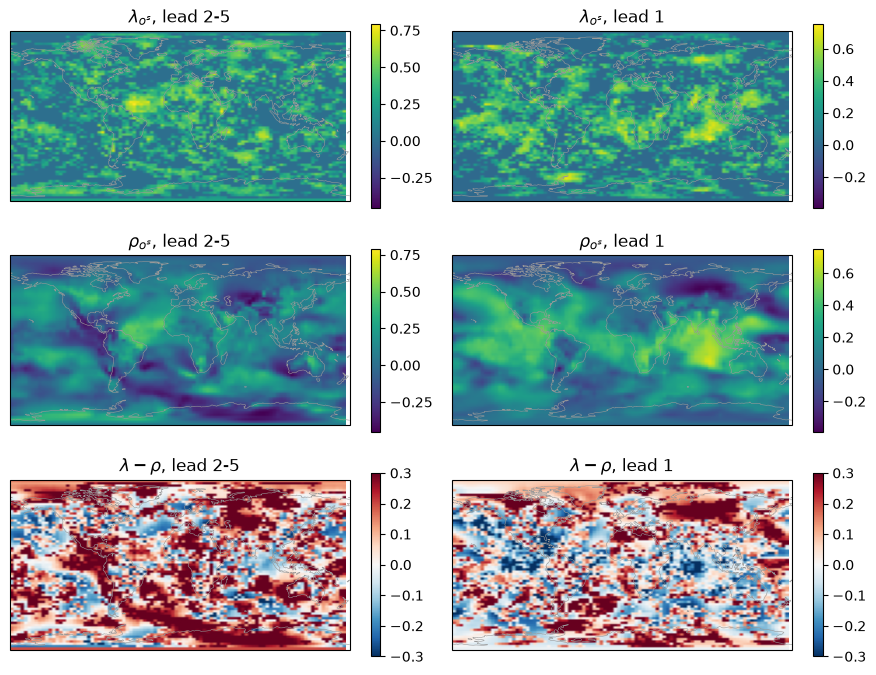

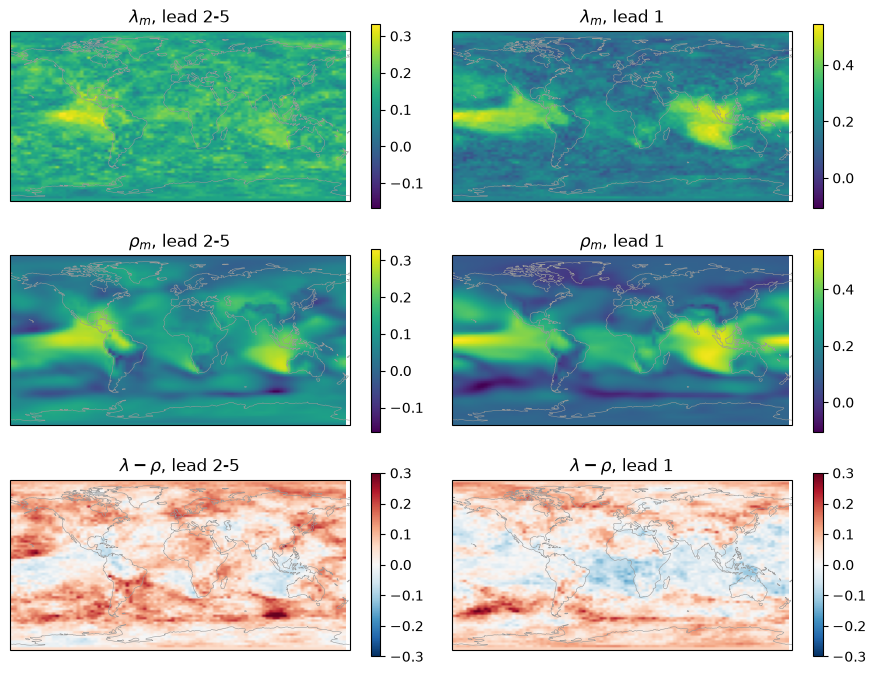

In [5]:
for name, A, B in (("o^s", LAM_O_S, RHO_O_S), ("m", LAM_M, RHO_M)):
    fig, axs = plt.subplots(3, 2, figsize=(9, 7), subplot_kw={"projection": PROJ})
    for i, w in enumerate(WINDOWS):
        a, b = A[w], B[w]
        nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                        max(np.nanmax(a), np.nanmax(b)))
        h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_{%s}$, %s" % (name, w))
        h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_{%s}$, %s" % (name, w))
        h2 = panel(axs[2, i], a - b, "RdBu_r", Normalize(-0.3, 0.3),
                   "$\\lambda-\\rho$, %s" % w)
        for ax, h in zip(axs[:, i], (h0, h1, h2)):
            fig.colorbar(h, ax=ax, shrink=0.85, label="")
    plt.tight_layout()
    plt.show()

## On Eade's spatial scale

Eade et al. smooth their maps over $12.5^\circ$ latitude by $11.25^\circ$ longitude, which
on N48 is exactly $5\times3$ cells. Taking *non-overlapping* $5\times3$ block means gives a
$15\times32$ grid of 480 near-independent boxes at the paper's resolution, and unlike a
running mean it does not manufacture the 15-fold redundancy that makes area fractions look
better determined than they are. It also gives MI something to work with: a block average
of 15 cells has far better signal-to-noise than one cell, at the same $J=45$.

Same estimators, same null -- the series are still 45 points long, so the floor does not
move.

In [6]:
def block_mean(X, nlat=5, nlon=3):
    """Non-overlapping 5 lat x 3 lon block means: (..., 73, 96) -> (..., 15, 32).

    The last latitude block holds 3 rows, not 5, because 73 = 5*14 + 3.
    """
    ny, nx = X.shape[-2:]
    nby = -(-ny // nlat)
    out = np.empty(X.shape[:-2] + (nby, nx // nlon))
    for i in range(nby):
        blk = X[..., i * nlat:min(ny, (i + 1) * nlat), :]
        blk = blk.reshape(blk.shape[:-1] + (nx // nlon, nlon))
        out[..., i, :] = blk.mean(axis=(-3, -1))
    return out


BLAT = block_mean(np.broadcast_to(lats[:, None], (lats.size, 3)).copy())[:, 0]
BLON = block_mean(np.broadcast_to(lons[None, :], (5, lons.size)).copy())[0]
BW = np.cos(np.deg2rad(BLAT))[:, None] * np.ones(BLON.size)
_b180 = ((BLON + 180) % 360) - 180
BORDER = np.argsort(_b180)
BEXT = [_b180[BORDER].min(), _b180[BORDER].max(), BLAT.min(), BLAT.max()]


def bgm(a):
    """Area-weighted mean on the block grid."""
    m = np.isfinite(a)
    return float((a[m] * BW[m]).sum() / BW[m].sum())


BLOCK = {}
for w in WINDOWS:
    Fb, Gb = block_mean(FIELDS[w][0]), block_mean(FIELDS[w][1])
    s = Fb.mean(axis=0)
    lam_o_s = lam(excess_mi(mi_field(s, Gb)))
    lam_m = lam(excess_mi(np.stack(
        [mi_field(Fb[n], loo_mean(Fb, n)) for n in range(N)]))).mean(axis=0)
    tot = Fb.var(axis=1).mean(axis=0)
    _num = N * s.var(axis=0) - tot
    with np.errstate(invalid="ignore"):
        deb = np.sqrt(np.where(_num > 0, _num, np.nan) / ((N - 1) * tot))
    BLOCK[w] = {"lam_o^s": lam_o_s, "lam_m": lam_m, "rho_o^s": rho_pair(s, Gb),
                "rho_m": np.sqrt(s.var(axis=0) / tot), "rho_m deb": deb}

print("480 blocks of 5 lat x 3 lon = 12.5 x 11.25 deg, Eade's smoothing scale")
print("%-10s %8s %9s %8s %10s | %7s %11s %8s %9s"
      % ("window", "lam_o^s", "rho_o^s", "rho_m", "rho_m deb",
         "rho^s", "rho^s deb", "lam^s", "boxes>1"))
for w in WINDOWS:
    b = BLOCK[w]
    print("%-10s %8.4f %+9.4f %8.4f %10.4f | %7.3f %11.3f %8.3f %8.1f%%"
          % (w, bgm(b["lam_o^s"]), bgm(b["rho_o^s"]), bgm(b["rho_m"]),
             bgm(b["rho_m deb"]), bgm(b["rho_o^s"] / b["rho_m"]),
             bgm(b["rho_o^s"] / b["rho_m deb"]), bgm(b["lam_o^s"] / b["lam_m"]),
             100 * np.mean(b["rho_o^s"] / b["rho_m"] > 1)))

480 blocks of 5 lat x 3 lon = 12.5 x 11.25 deg, Eade's smoothing scale
window      lam_o^s   rho_o^s    rho_m  rho_m deb |   rho^s   rho^s deb    lam^s   boxes>1
lead 2-5     0.1766   +0.0490   0.2376     0.1527 |   0.228       0.407    1.218     14.8%
lead 1       0.2143   +0.1780   0.3200     0.2590 |   0.490       0.624    1.061     12.3%


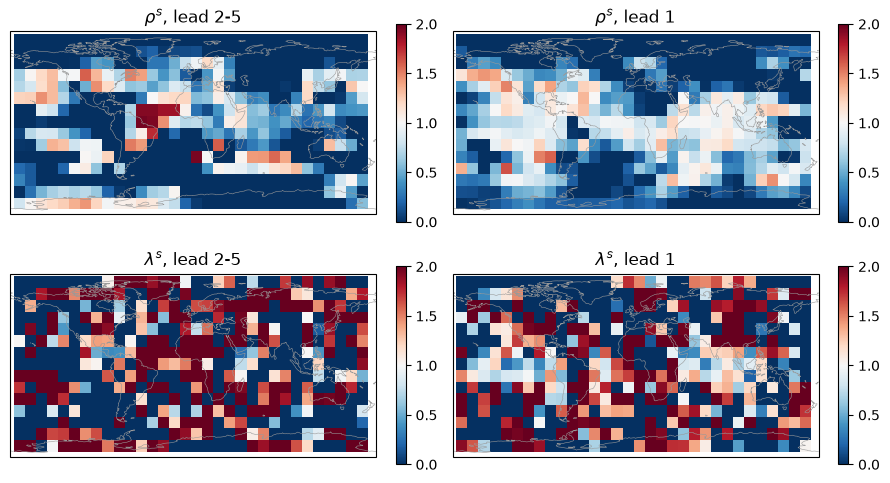

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(9, 5), subplot_kw={"projection": PROJ})
for i, w in enumerate(WINDOWS):
    b = BLOCK[w]
    h0 = panel(axs[0, i], b["rho_o^s"] / b["rho_m"], "RdBu_r", Normalize(0, 2),
               "$\\rho^s$, %s" % w, BORDER, BEXT)
    h1 = panel(axs[1, i], b["lam_o^s"] / b["lam_m"], "RdBu_r", Normalize(0, 2),
               "$\\lambda^s$, %s" % w, BORDER, BEXT)
    fig.colorbar(h0, ax=axs[0, i], fraction=0.025)
    fig.colorbar(h1, ax=axs[1, i], fraction=0.025)
plt.tight_layout()
plt.show()

## The indices, and the external anchor

This is the part comparable to the paper. Eade et al. (2014) Figure 3b reports $r=0.71$
and RPC $=2.4$ for the MDR index -- the area-average MSLP anomaly over 10-20$^\circ$N,
60-20$^\circ$W at lead years 2-5 -- the one external scalar the study pins down. An area
average over $5\times11$ cells *is* the smoother, so nothing further is applied.

The NAO is here because DJF is the window: the Azores box (35-40$^\circ$N,
20-30$^\circ$W) minus the Iceland box (62.5-67.5$^\circ$N, 15-25$^\circ$W). Note what it is
*not*. Eade et al.'s winter NAO result comes from a seasonal system initialised weeks
ahead, not from CMIP5 decadal hindcasts verified a year or more out, so a low value here is
not a contradiction of theirs.

The first row is the validation: the same index code, run on the lead-years-2-5 *annual*
cube the replication pipeline built, has to land on that pipeline's stored MDR numbers and
near Eade's published pair. Intervals are a paired bootstrap over start dates, 2000
resamples, 90%.

In [8]:
MDR = (10.0, 20.0, 300.0, 340.0)            # 10-20N, 60-20W -- Eade fig 3b
AZORES, ICELAND = (35.0, 40.0, 330.0, 340.0), (62.5, 67.5, 335.0, 345.0)
EADE_MDR = (0.71, 2.4)                      # published r, RPC
PIPE_MDR = (0.6575, 0.3545, 1.855)          # the replication pipeline's stored MDR
NBOOT = 2000


def area_mean(X, box, lat=None, lon=None):
    """cos(lat)-weighted mean over a box; X has trailing (lat, lon) axes."""
    lat = lats if lat is None else lat
    lon = lons if lon is None else lon
    iy = np.where((lat >= box[0]) & (lat <= box[1]))[0]
    ix = np.where((lon >= box[2]) & (lon <= box[3]))[0]
    w = np.cos(np.deg2rad(lat[iy]))[:, None] * np.ones(ix.size)
    return (X[..., iy, :][..., :, ix] * w).sum((-2, -1)) / w.sum()


def index_pair(Fx, Gx, name, lat=None, lon=None):
    """(F, g) for one index: F is (N, J), g is (J,)."""
    if name == "NAO":
        return (area_mean(Fx, AZORES, lat, lon) - area_mean(Fx, ICELAND, lat, lon),
                area_mean(Gx, AZORES, lat, lon) - area_mean(Gx, ICELAND, lat, lon))
    return area_mean(Fx, MDR, lat, lon), area_mean(Gx, MDR, lat, lon)


def rpc_parts(Fi, g):
    """rho and lambda metrics for one index: Fi is (N, J), g is (J,)."""
    Nn = Fi.shape[0]
    s = Fi.mean(axis=0)
    tot = Fi.var(axis=1).mean()
    num = Nn * s.var() - tot
    out = {"rho_o^s": float(np.corrcoef(s, g)[0, 1]),
           "rho_m": float(np.sqrt(s.var() / tot)),
           "rho_m deb": float(np.sqrt(num / ((Nn - 1) * tot))) if num > 0 else np.nan}
    out["rho^s"] = out["rho_o^s"] / out["rho_m"]
    out["rho^s deb"] = out["rho_o^s"] / out["rho_m deb"]
    out["lam_o^s"] = float(lam(excess_mi(R.mi_bits(s, g, "ksg", param=K))))
    out["lam_m"] = float(np.mean([
        lam(excess_mi(R.mi_bits(Fi[n], (Fi.sum(0) - Fi[n]) / (Nn - 1), "ksg", param=K)))
        for n in range(Nn)]))
    out["lam^s"] = out["lam_o^s"] / out["lam_m"] if out["lam_m"] > 0 else np.nan
    return out


def boot_ci(Fi, g, seed=0, nboot=NBOOT):
    """Paired bootstrap over start dates for rho^s, 90% interval."""
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(nboot):
        k = rng.integers(0, Fi.shape[1], Fi.shape[1])
        Fk, gk = Fi[:, k], g[k]
        sk = Fk.mean(axis=0)
        vals.append(np.corrcoef(sk, gk)[0, 1] / np.sqrt(sk.var() / Fk.var(axis=1).mean()))
    return np.percentile(vals, [5, 95])


ROWS = []
_S = ("../.scratch/eade_replication" if os.path.isdir("../.scratch/eade_replication")
      else "/Users/jasperchen/Academics/Research/SNP/information-snp/"
           ".scratch/eade_replication")
if os.path.exists(_S + "/data/full_cube.npz"):
    _a = np.load(_S + "/data/full_cube.npz", allow_pickle=True)
    _f, _g = index_pair(detrend(_a["cube"].astype(float)).transpose(1, 0, 2, 3),
                        detrend(_a["obs"].astype(float)), "MDR", _a["lat"], _a["lon"])
    ROWS.append(("annual lead 2-5", "MDR", rpc_parts(_f, _g), boot_ci(_f, _g)))

for w in WINDOWS:
    Fx, Gx = FIELDS[w]
    for nm in ("MDR", "NAO"):
        f, g = index_pair(Fx, Gx, nm)
        ROWS.append(("DJF " + w, nm, rpc_parts(f, g), boot_ci(f, g)))

print("%-16s %-4s %8s %8s %10s %8s %10s %16s %9s %7s"
      % ("window", "idx", "rho_o^s", "rho_m", "rho_m deb", "rho^s", "rho^s deb",
         "rho^s 90% CI", "lam_o^s", "lam^s"))
for tag, nm, m, ci in ROWS:
    print("%-16s %-4s %+8.4f %8.4f %10.4f %8.3f %10.3f %16s %9.4f %7.3f"
          % (tag, nm, m["rho_o^s"], m["rho_m"], m["rho_m deb"], m["rho^s"],
             m["rho^s deb"], "[%.2f, %.2f]" % tuple(ci), m["lam_o^s"], m["lam^s"]))

if ROWS and ROWS[0][0] == "annual lead 2-5":
    _v = ROWS[0][2]
    print("\nvalidation on the annual lead-2-5 MDR index:")
    print("  rho_o^s %.4f vs pipeline %.4f | rho_m %.4f vs %.4f | RPC %.3f vs %.3f"
          % (_v["rho_o^s"], PIPE_MDR[0], _v["rho_m"], PIPE_MDR[1],
             _v["rho^s"], PIPE_MDR[2]))
    print("  Eade et al. fig 3b, same index: r = %.2f, RPC = %.1f  (70 members, not 29)"
          % EADE_MDR)

window           idx   rho_o^s    rho_m  rho_m deb    rho^s  rho^s deb     rho^s 90% CI   lam_o^s   lam^s
annual lead 2-5  MDR   +0.6575   0.3545     0.3073    1.855      2.139     [1.49, 2.23]    0.7589   3.369
DJF lead 2-5     MDR   +0.5013   0.2386     0.1525    2.101      3.287     [1.53, 2.67]    0.6310   4.581
DJF lead 2-5     NAO   +0.1493   0.2505     0.1710    0.596      0.873    [-0.50, 1.61]    0.0000   0.000
DJF lead 1       MDR   +0.2674   0.3018     0.2421    0.886      1.105     [0.20, 1.53]    0.0000   0.000
DJF lead 1       NAO   +0.1194   0.2015     0.0795    0.593      1.501    [-0.71, 1.72]    0.0000   0.000

validation on the annual lead-2-5 MDR index:
  rho_o^s 0.6575 vs pipeline 0.6575 | rho_m 0.3545 vs 0.3545 | RPC 1.855 vs 1.855
  Eade et al. fig 3b, same index: r = 0.71, RPC = 2.4  (70 members, not 29)


## What came out

**The index reproduces Eade et al.; an area-weighted mean of per-cell RPC does not, and
should not.** Run on the replication pipeline's annual lead-2-5 cube, the MDR index code
here returns $\rho_o^s=0.6575$, $\rho_m=0.3545$, RPC $=1.855$ -- the pipeline's stored
values to four decimals, below Eade's published $r=0.71$, RPC $=2.4$ by about what 29
members against their 70 costs. On the DJF lead-2-5 winters the same index gives
$\rho_o^s=+0.50$ and RPC $=2.10$, with a 90% bootstrap interval $[1.53,\,2.67]$ that
contains Eade's 2.4, rising to 3.29 once $\rho_m$ is debiased for
$\sigma^2_{\mathrm{noise}}/N$. The paradox is there, at the paper's magnitude, in winter.

The per-cell global mean is 0.23 for that same window, and the block grid gives 0.23 too.
Neither contradicts the paper. Per cell at $J=45$, $\rho_o$ averages $+0.01$ and half of
all member-cells fall below the MI noise floor; an area-weighted mean of a ratio of two
small noisy numbers over 7008 cells is not a quantity Eade et al. report, and the
replication pipeline's own per-cell global mean on the annual cube, 0.27-0.44, is equally
far from its own index value of 1.855. Aggregation is not a detail here -- it is the
difference between 0.23 and 2.10 on the same data.

**The verification window is the other half.** One winter at 12-14 months lead (`lead 1`)
gives MDR RPC $=0.89$, interval $[0.20,\,1.53]$; the four winters of lead years 2-5 give
2.10. Most of the ensemble-mean skill in the tropical Atlantic is in the multi-winter
average, not in a single seasonal forecast, which is why Eade et al. verify lead years 2-5
for the decadal systems.

**Detrending costs the lead-2-5 window far more than the lead-1 one**, and in opposite
proportion to what a global glance suggests: per-cell $\rho_o^s$ falls 0.204 to 0.049 for
lead 2-5 but only 0.189 to 0.174 for lead 1. A four-winter mean is dominated by the forced
trend, so removing it removes most of the globally-averaged agreement -- while the MDR
index keeps $+0.50$. Skill that survives detrending is regional and low-frequency, not
global.

**The NAO is not a test of their result.** It sits at RPC $\approx0.6$ with an interval
spanning one in both windows. Eade et al.'s winter NAO finding comes from a seasonal system
initialised weeks ahead; these are CMIP5 decadal hindcasts verified a year or more out, so
a null result here says nothing about theirs.

**$\lambda$ at $J=45$ needs the bias correction and only survives where the correlation is
large.** The pooled permutation null is 0.0485 bits, i.e. $\lambda=0.255$ from independent
noise alone, and it is the same constant for every pairing, window and aggregation, as the
rank transform requires. After subtracting it, $\lambda_o^s$ is non-zero on exactly the two
rows where $\rho_o^s$ is large -- 0.759 on the annual MDR index and 0.632 on the DJF
lead-2-5 MDR index -- and clamps to exactly zero on the NAO and on lead-1 MDR. Per cell it
is mostly clamp on both sides.

So read the $\lambda$-based ratios with care. $\lambda^s$ reaches 3.3-4.5 on the MDR
indices against $\rho^s$ of 1.9-2.1, not because it measures more skill but because
$\lambda=\sqrt{1-2^{-2I}}$ is concave in $I$ and its denominator $\lambda_m$ sits near the
floor: a ratio of two clamped quantities is not on the same scale as a ratio of two
correlations. The $\lambda$ column is informative about *whether* information survives the
null, not yet about how much.

The null is resampled on every execution, so the third decimal of every $\lambda$ moves a
little between runs; nothing here turns on it.